<a href="https://colab.research.google.com/github/BugDroi/Buzzwole/blob/main/NSFW%E6%A4%9C%E5%87%BA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 必要なライブラリのインストール（出力を非表示に設定）
print("Installing libraries...")
!pip install git+https://github.com/openai/CLIP.git ftfy regex tqdm matplotlib datasets opencv-python-headless -q

# 日本語フォントのインストール（出力を非表示に設定）
!apt-get -y install fonts-ipaexfont-gothic -q

# グラフの日本語表示設定
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'IPAexGothic'

# 警告メッセージの非表示設定
import logging
import warnings
import os

logging.getLogger('matplotlib').setLevel(logging.ERROR)
logging.getLogger('huggingface_hub').setLevel(logging.ERROR)
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
warnings.filterwarnings('ignore')

print("Setup complete")

Installing libraries...
  Preparing metadata (setup.py) ... done
Reading package lists...
Building dependency tree...
Reading state information...
fonts-ipaexfont-gothic is already the newest version (00401-3ubuntu1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.
Setup complete


In [ ]:
import torch
import clip
from PIL import Image
import numpy as np
import random
from datasets import load_dataset
import os # ファイル存在チェックのために追加

# --- USER CONFIGURATION ---
# 画像の読み込みモードを選択してください。
image_loading_mode = "Random 5 Images" # @param ["Random 5 Images", "Load Specific File"]

# 「Load Specific File」を選択した場合、ここに画像ファイルのパスを指定してください。
# 例: specific_image_path = "/content/my_image.jpg"
specific_image_path = "HGY0WcpbkAAlalC.jpg" # @param {type:"string"}
# -------------------------


# 1. 基本設定
MODEL_NAME = "ViT-B/32"
DATASET_NAME = "Gprime1977/AnimeGirlz"

# 判定ラベル
LABEL_MAP = [
    ("a modest and polite anime girl", "Safe: Casual"),
    ("an anime girl in school uniform", "Safe: School"),
    ("an anime character in armor", "Safe: Armor"),
    ("an anime girl in a swimsuit", "Warning: Swimsuit"),
    ("revealing clothes and bare skin", "Sensitive: Exposure"),
    ("seductive or suggestive pose", "Sensitive: Pose"),
    ("explicit or NSFW illustration", "Danger: Explicit")
]

# 2. AIモデルの準備
device = "cuda" if torch.cuda.is_available() else "cpu"
model, preprocess = clip.load(MODEL_NAME, device=device)

english_labels = [m[0] for m in LABEL_MAP]
short_labels = [m[1] for m in LABEL_MAP]
text_tokens = clip.tokenize(english_labels).to(device)

# 3. 判定結果を評価する関数
def generate_review(probs):
    max_idx = np.argmax(probs)
    safe_score = probs[0] + probs[1] + probs[2]
    sensitive_score = probs[4] + probs[5] + probs[6]

    if safe_score > 0.6:
        res = "Status: SAFE"
    elif sensitive_score > 0.4:
        res = "Status: WARNING"
    else:
        res = "Status: BORDERLINE"

    res += f" / Top Trait: {short_labels[max_idx]} ({probs[max_idx]:.1%})"
    return res

# 4. データの読み込み
images = []
if image_loading_mode == "Random 5 Images":
    print("Loading random images from dataset...")
    # seedにランダムな数値を渡すことで、実行するたびに違う画像が選ばれます
    random_seed = random.randint(0, 100000)
    dataset = load_dataset(DATASET_NAME, split="train", streaming=True).shuffle(seed=random_seed, buffer_size=1000)

    # シャッフルされたデータから先頭5枚を取り出す
    for item in dataset.take(5):
        images.append(item['image'])

    print(f"Ready (Seed: {random_seed})")
elif image_loading_mode == "Load Specific File":
    if not specific_image_path:
        print("Error: 'specific_image_path' を指定してください。")
    elif not os.path.exists(specific_image_path):
        print(f"Error: ファイル '{specific_image_path}' が見つかりません。パスを確認してください。")
    else:
        print(f"Loading image from {specific_image_path}...")
        try:
            img = Image.open(specific_image_path).convert("RGB")
            images.append(img)
            print(f"Successfully loaded 1 image: {specific_image_path}")
        except Exception as e:
            print(f"Error loading image from {specific_image_path}: {e}")
else:
    print("Invalid image_loading_mode specified.")

if not images:
    print("No images were loaded. Please check your settings.")


Loading random images from dataset...


Resolving data files:   0%|          | 0/998 [00:00<?, ?it/s]

Ready (Seed: 93404)


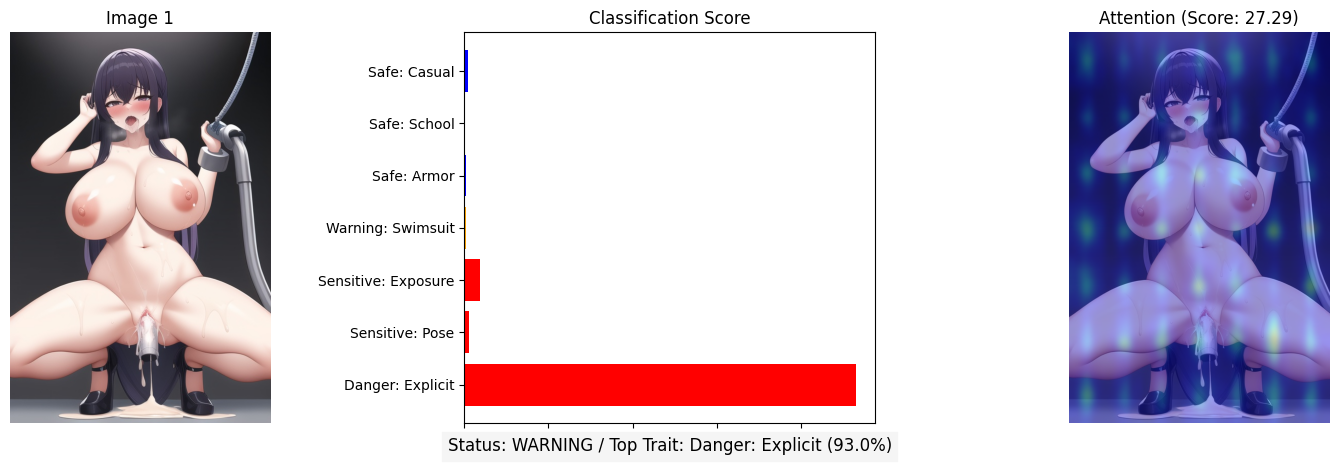

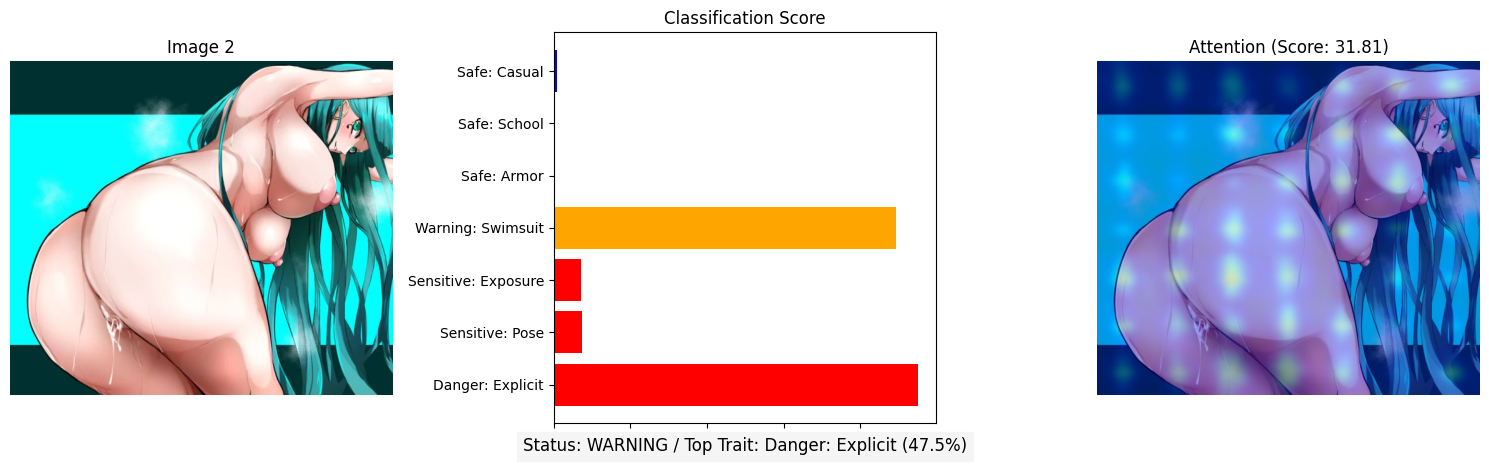

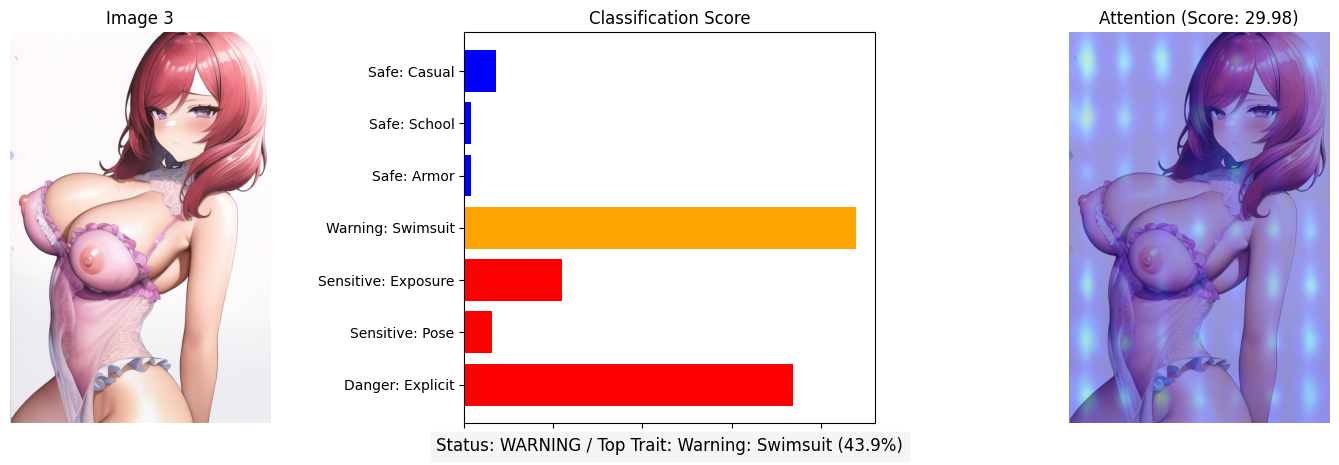

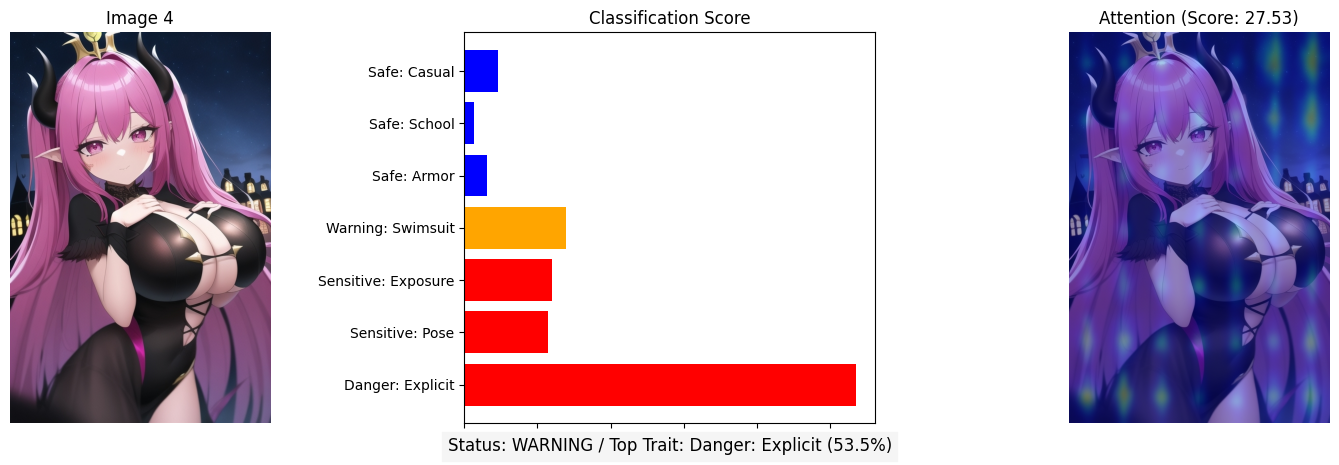

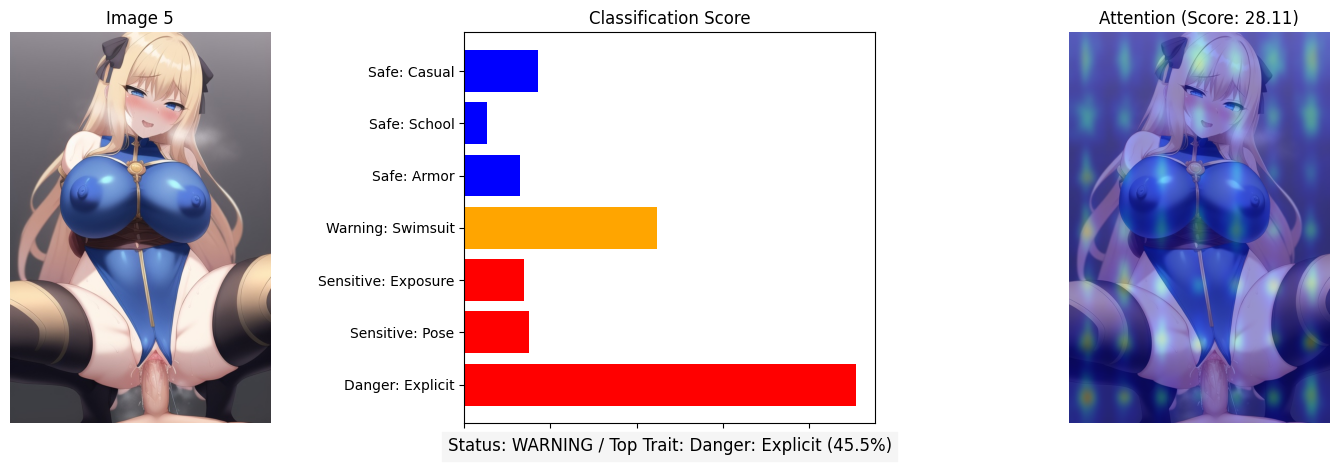

In [ ]:
import cv2

# 1. 注目ターゲットの設定
target_text = "a character in a suggestive or revealing outfit"
target_tokens = clip.tokenize([target_text]).to(device)

def make_heatmap(pil_img, alpha=0.4):
    # 画像の準備
    img_rgb = pil_img.convert("RGB")
    img_input = preprocess(img_rgb).unsqueeze(0).to(device)

    # 勾配計算を有効にする
    img_input.requires_grad = True

    # スコアの計算
    image_features = model.encode_image(img_input)
    text_features = model.encode_text(target_tokens)
    score = torch.matmul(image_features, text_features.t())

    # 勾配を逆伝播させて、どの画素がスコアに影響したか特定する
    model.zero_grad()
    score.backward()

    # 影響度（勾配）を抽出
    grads = img_input.grad.abs().max(dim=1)[0][0].cpu().numpy()

    # ヒートマップ化してぼかしを入れる
    grads_min = grads.min()
    grads_max = grads.max()

    if grads_max == grads_min:
        # If all gradients are the same, it means no particular region has more attention.
        # Initialize as zeros, which will result in a uniform blue heatmap with COLORMAP_JET.
        grads_norm = np.zeros_like(grads, dtype=np.float32)
    else:
        # Normalize gradients to 0-1 range
        grads_norm = (grads - grads_min) / (grads_max - grads_min)

        # Apply a power transformation to enhance contrast.
        # Gamma < 1 emphasizes lower values, making subtle attention more visible.
        # Gamma > 1 emphasizes higher values, making strong attention more prominent.
        # A value like 0.5 (square root) often works well to boost visibility.
        gamma = 0.5
        grads_norm = np.power(grads_norm, gamma)


    heatmap = cv2.applyColorMap(np.uint8(255 * grads_norm), cv2.COLORMAP_JET)
    heatmap = cv2.GaussianBlur(heatmap, (15, 15), 0)

    # 元画像と合成
    img_cv = cv2.cvtColor(np.array(img_rgb), cv2.COLOR_RGB2BGR)
    heatmap_resized = cv2.resize(heatmap, (img_cv.shape[1], img_cv.shape[0]))
    # alphaパラメータを使用してブレンド比率を調整
    blended = cv2.addWeighted(img_cv, 1 - alpha, heatmap_resized, alpha, 0)

    # ここで結果を返します
    return cv2.cvtColor(blended, cv2.COLOR_BGR2RGB), score.item()

# 2. 実行ループ
for i, img_obj in enumerate(images):
    # 分類用の判定
    img_input_cls = preprocess(img_obj).unsqueeze(0).to(device)
    with torch.no_grad():
        logits_per_image, _ = model(img_input_cls, text_tokens)
        probs = logits_per_image.softmax(dim=-1).cpu().numpy()[0]

    # ヒートマップ作成（関数を呼び出し）
    # デフォルトのalpha値 (0.4) が使用されます。必要に応じて変更できます。
    heat_img, attn_score = make_heatmap(img_obj)
    review_text = generate_review(probs)

    # UI表示
    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(img_obj)
    plt.title(f"Image {i+1}")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    colors = ['blue']*3 + ['orange'] + ['red']*3
    plt.barh(short_labels, probs, color=colors)
    plt.gca().invert_yaxis()
    plt.title("Classification Score")

    plt.subplot(1, 3, 3)
    plt.imshow(heat_img)
    plt.title(f"Attention (Score: {attn_score:.2f})")
    plt.axis("off")

    plt.suptitle(review_text, y=0.05, fontsize=12, backgroundcolor='whitesmoke')
    plt.tight_layout()
    plt.show()